Segmentation inspection

Code to insepct the result of the segmentation and make sure the bounding boxes contained in the label files are indeed matching the position of the waterholes on the segmented images. 

Sublecting randomlz 16 images to inspect. Would need to rerun the code to have a more extensive inspection. 

Let's first define all the function that will be used later and used in the future all integrated:

In [2]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

def load_image(image_path):
    """Load an image using PIL."""
    return np.array(Image.open(image_path))

def load_labels(label_path):
    """Load bounding box labels from a text file."""
    boxes = []
    try:
        with open(label_path, 'r') as file:
            for line in file:
                values = line.strip().split()
                if len(values) == 5:  # Ensure we have all 5 values
                    class_id, center_x, center_y, width, height = map(float, values)
                    boxes.append((class_id, center_x, center_y, width, height))
    except FileNotFoundError:
        print(f"Warning: Label file not found: {label_path}")
    except Exception as e:
        print(f"Error reading label file {label_path}: {e}")
    
    return boxes

def get_color_for_class(class_id):
    """Return a color based on the class_id."""
    # Define colors for classes 0-4
    colors = {
        0: 'red',
        1: 'blue',
        2: 'green',
        3: 'purple',
        4: 'orange'
    }
    
    # Default color for any classes beyond our defined range
    return colors.get(int(class_id), 'gray')

def plot_bounding_boxes(ax, boxes, img_width, img_height):
    """Plot bounding boxes on the given axis with colors based on class_id."""
    for box in boxes:
        class_id, center_x, center_y, width, height = box
        
        # Get color for this class
        color = get_color_for_class(class_id)
        
        # Convert normalized coordinates to pixel coordinates
        x = (center_x - width/2) * img_width
        y = (center_y - height/2) * img_height
        box_width = width * img_width
        box_height = height * img_height
        
        # Create a rectangle patch with the class color
        rect = patches.Rectangle(
            (x, y), box_width, box_height, 
            linewidth=2, edgecolor=color, facecolor='none'
        )
        
        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add class label at the top-right corner of the box
        # This ensures the label doesn't cover the content of the box
        ax.text(
            x + box_width, y, f'Class {int(class_id)}',
            color='white', fontsize=8, 
            bbox=dict(facecolor=color, alpha=0.7),
            horizontalalignment='left',
            verticalalignment='top'
        )

def visualize_random_images_with_boxes(
    images_dir,
    labels_dir,
    num_images,
    output_path 
):
    """
    Visualize a mosaic of random images with their bounding boxes.
    
    Args:
        images_dir: Directory containing the image files
        labels_dir: Directory containing the label files
        num_images: Number of images to display (should be a perfect square)
        output_path: Path to save the visualization as PNG
    """
    # Get all PNG files in the images directory
    image_files = [f for f in os.listdir(images_dir) if f.endswith('.png')]
    
    if len(image_files) < num_images:
        print(f"Warning: Only {len(image_files)} images available, requested {num_images}")
        num_images = min(len(image_files), num_images)
    
    # Randomly select images
    selected_images = random.sample(image_files, num_images)
    
    # Calculate grid dimensions
    grid_size = int(np.sqrt(num_images))
    
    # Create figure and subplots
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    
    # Flatten axes array for easier iteration
    axes = axes.flatten()
    
    for i, image_file in enumerate(selected_images):
        # Construct paths
        image_path = os.path.join(images_dir, image_file)
        label_path = os.path.join(labels_dir, os.path.splitext(image_file)[0] + '.txt')
        
        # Load image and labels
        image = load_image(image_path)
        boxes = load_labels(label_path)
        
        # Display image
        axes[i].imshow(image)
        
        # Plot bounding boxes
        plot_bounding_boxes(axes[i], boxes, image.shape[1], image.shape[0])
        
        # Set title (filename)
        axes[i].set_title(image_file, fontsize=8)
        
        # Remove axis ticks
        axes[i].set_xticks([])
        axes[i].set_yticks([])
    
    # Add a legend to show class colors
    legend_elements = [
        patches.Patch(facecolor=get_color_for_class(i), edgecolor=get_color_for_class(i), 
                     label=f'Class {i}') for i in range(5)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5, frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for the legend
    
    # Save the figure as PNG
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Visualization saved to {output_path}")
    
    # Display the figure
    plt.show()




All the function are defined, now we can print the image and save it.  

Visualization saved to C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\results\Check_segment\bbox_visualization.png


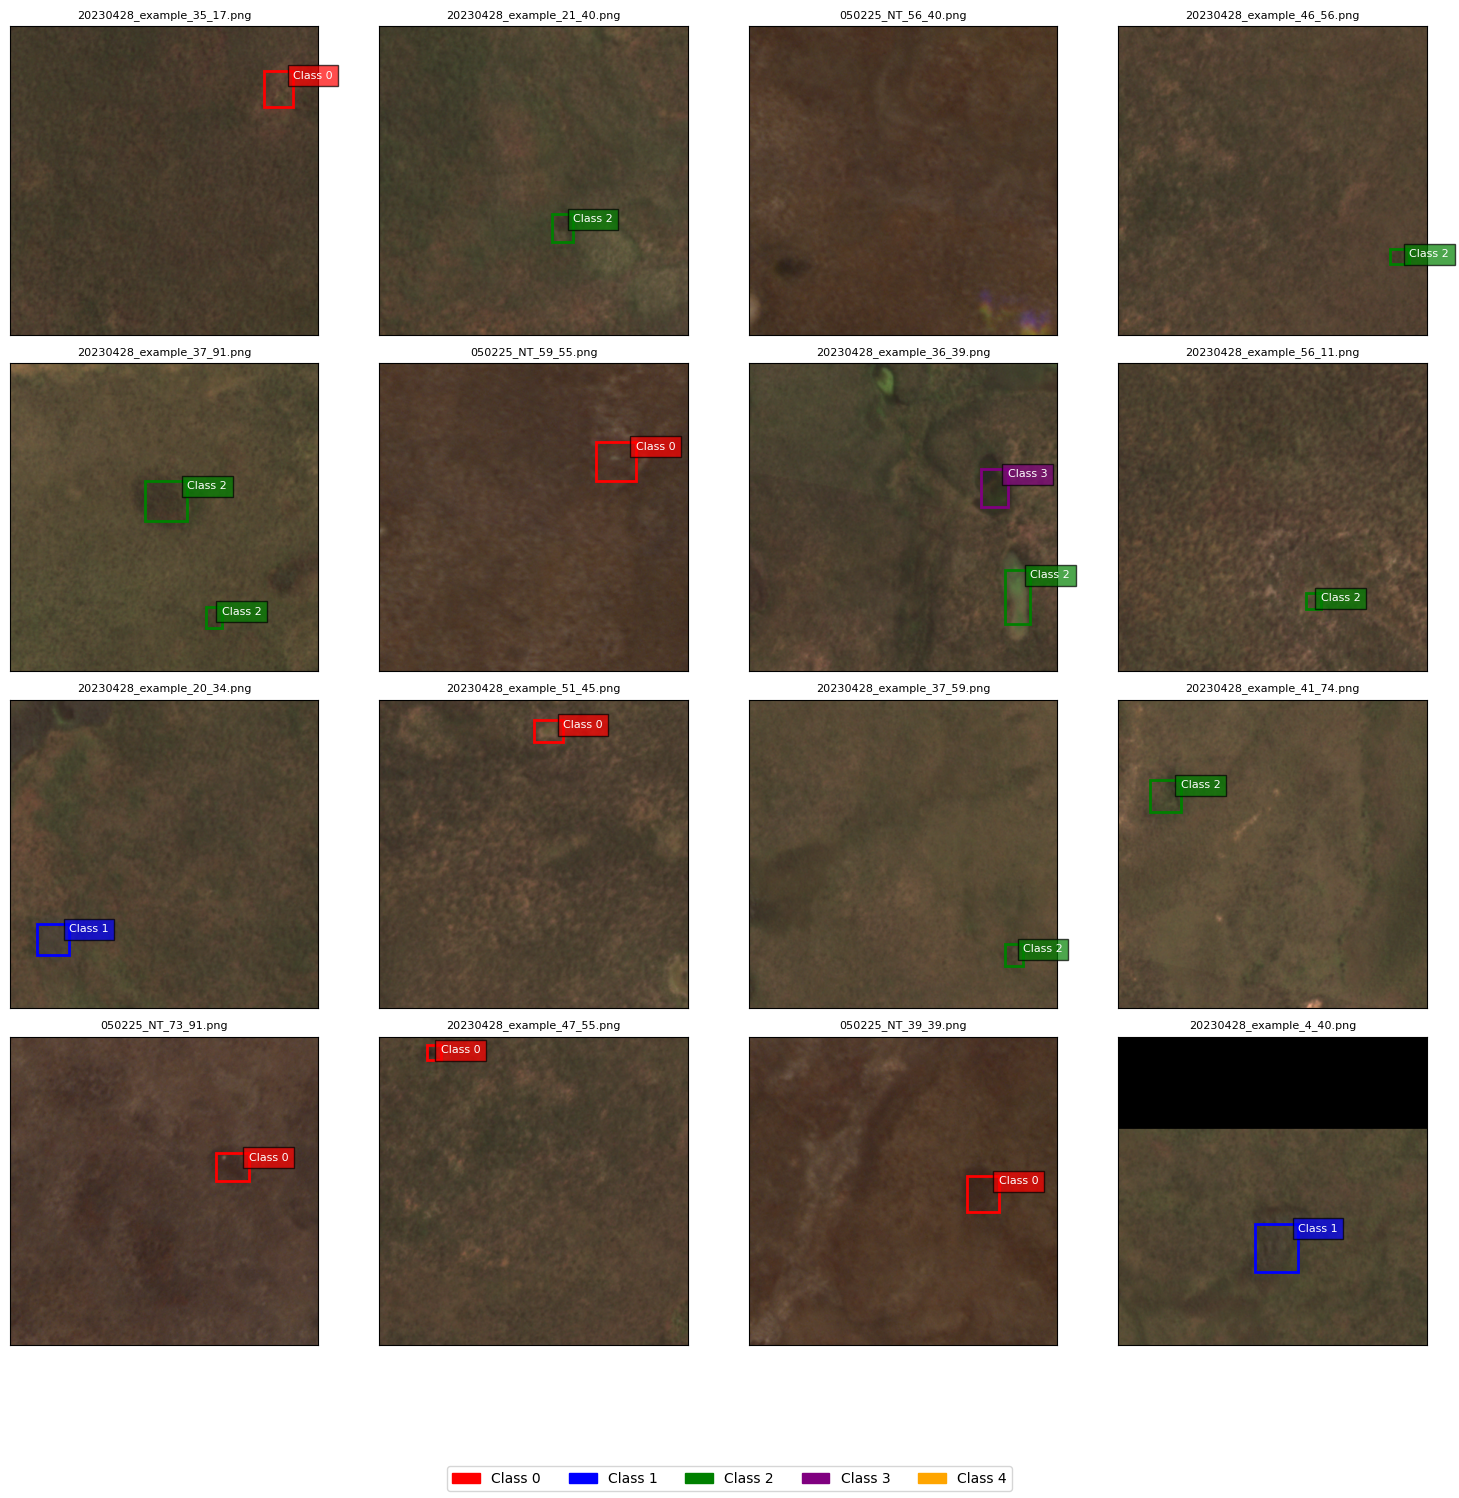

In [4]:
visualize_random_images_with_boxes(r"C:\Users\fossatia\OneDrive - Queensland University of Technology\FirstByte Waterholes WD\counting_waterholes\training\run_3_archive_GPU\train\images", 
                                   r"C:\Users\fossatia\OneDrive - Queensland University of Technology\FirstByte Waterholes WD\counting_waterholes\training\run_3_archive_GPU\train\labels", 
                                   16, 
                                   r"C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\results\Check_segment\bbox_visualization.png"
                                   )

# if __name__ == "__main__":
#     visualize_random_images_with_boxes()

After the segmentation, the plotting of the boxes seem to be correctly placed but their size does not correspond to my plotting on labelme. Their size seems smaller. I now want to explore this by plotting the whole image. 

In [10]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

def plot_labelme_bboxes(image_dir, label_dir, output_dir=None, classes_colors=None, show_plots=True):
    """
    Plot bounding boxes from LabelMe annotation files onto their corresponding images.
    
    Parameters:
    -----------
    image_dir : str
        Directory containing the image files (.png).
    label_dir : str
        Directory containing the LabelMe annotation files (.json).
    output_dir : str, optional
        Directory to save the annotated images. If None, images won't be saved.
    classes_colors : dict, optional
        Dictionary mapping class names to colors. If None, random colors will be assigned.
    show_plots : bool, optional
        Whether to display the plots. Default is True.
        
    Returns:
    --------
    None
    """

    # Create output directory if specified
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Get all JSON files in the label directory
    json_files = [f for f in os.listdir(label_dir) if f.endswith('.json')]
    
    # Dictionary to store class colors
    if classes_colors is None:
        classes_colors = {}
    
    for json_file in json_files:
        # Load JSON file
        with open(os.path.join(label_dir, json_file), 'r') as f:
            data = json.load(f)
        
        # Get image filename
        image_filename = data['imagePath']
        
        # Handle relative paths or just filenames
        if os.path.isabs(image_filename):
            image_path = image_filename
        else:
            image_path = os.path.join(image_dir, os.path.basename(image_filename))
        
        # Check if image exists
        if not os.path.exists(image_path):
            print(f"Image {image_path} not found. Skipping...")
            continue
        
        # Open image
        img = np.array(Image.open(image_path))
        
        # Create figure and axis
        fig, ax = plt.subplots(1, figsize=(16, 10))
        ax.imshow(img)
        
        # Process each shape in the annotation
        for shape in data['shapes']:
            label = shape['label']
            points = shape['points']
            
            # Only process rectangle shapes (bounding boxes)
            if shape['shape_type'] == 'rectangle':
                # Get box coordinates
                x1, y1 = points[0]
                x2, y2 = points[1]
                
                # Calculate width and height
                width = x2 - x1
                height = y2 - y1
                
                # Assign color to class if not already assigned
                if label not in classes_colors:
                    # Generate random color
                    color = (random.random(), random.random(), random.random())
                    classes_colors[label] = color
                
                # Create rectangle patch
                rect = patches.Rectangle(
                    (x1, y1), width, height, 
                    linewidth=0.5, 
                    edgecolor=classes_colors[label],
                    facecolor='none'
                )
                
                # Add rectangle to plot
                ax.add_patch(rect)
                
                # Add label text
                # ax.text(
                #     x1, y1-5, 
                #     label,
                #     color=classes_colors[label],
                #     fontsize=12,
                #     weight='bold'
                # ) #AF: no need of the labels, just visual inspection of the boxes for the moment. 
        
        # Set title
        ax.set_title(f"Image: {os.path.basename(image_path)}")
        
        # Remove axis
        ax.axis('off')
        
        # Save image if output directory is specified
        if output_dir:
            output_path = os.path.join(output_dir, f"annotated_{os.path.basename(image_path)}")
            plt.savefig(output_path, bbox_inches='tight', dpi=300)
            print(f"Saved annotated image to {output_path}")
        
        # Show plot if specified
        if show_plots:
            plt.show()
        else:
            plt.close()
    
    return classes_colors  # Return the color mapping for future use

#-----------------------------------------#
# Example usage
# if __name__ == "__main__":
#     # Example directories
#     image_dir = "path/to/images"
#     label_dir = "path/to/labels"
#     output_dir = "path/to/output"
    
#     # Optional: Define specific colors for classes
#     # classes_colors = {
#     #     "person": (1, 0, 0),    # Red
#     #     "car": (0, 1, 0),       # Green
#     #     "dog": (0, 0, 1)        # Blue
#     # }
    
#     # Run the function
#     plot_labelme_bboxes(image_dir, label_dir, output_dir)

Run the function to check the boxes sizes:

c:\Users\fossatia\AppData\Local\miniconda3\envs\Boats\lib\site-packages\PIL\Image.py:3402: DecompressionBombWarning: Image size (105391104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Saved annotated image to C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\results\Check_whole_image\annotated_050225_NT.png


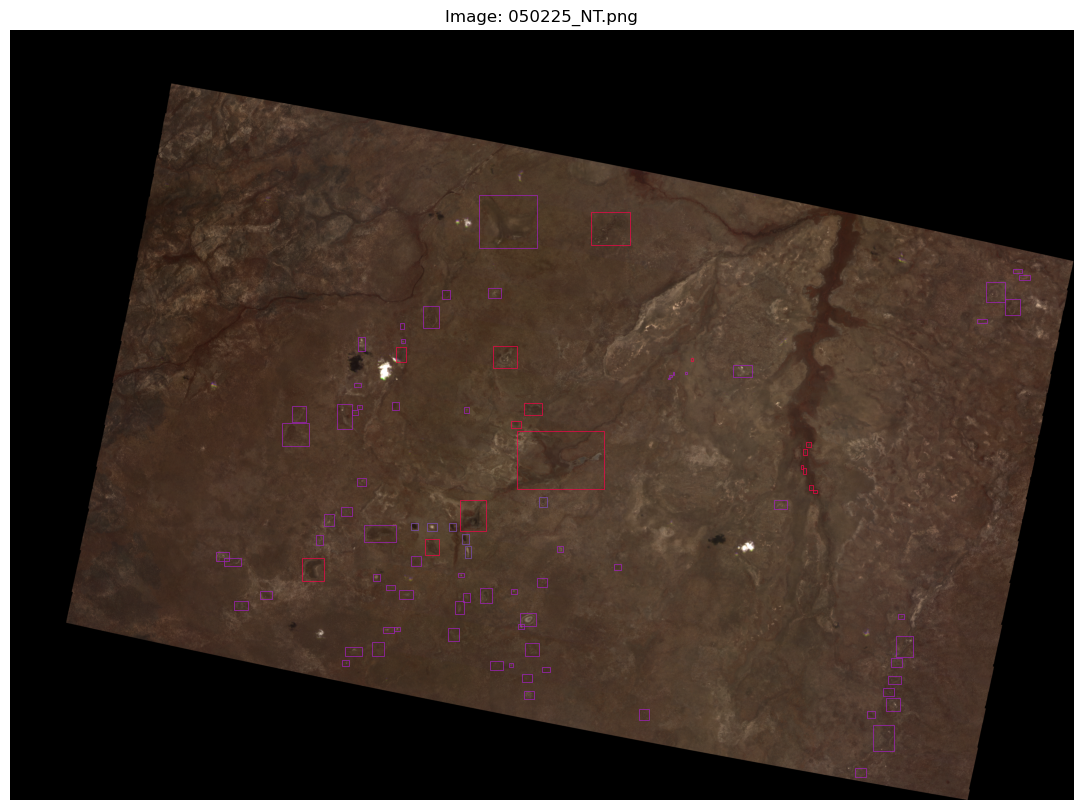

Saved annotated image to C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\results\Check_whole_image\annotated_20230428_example.png


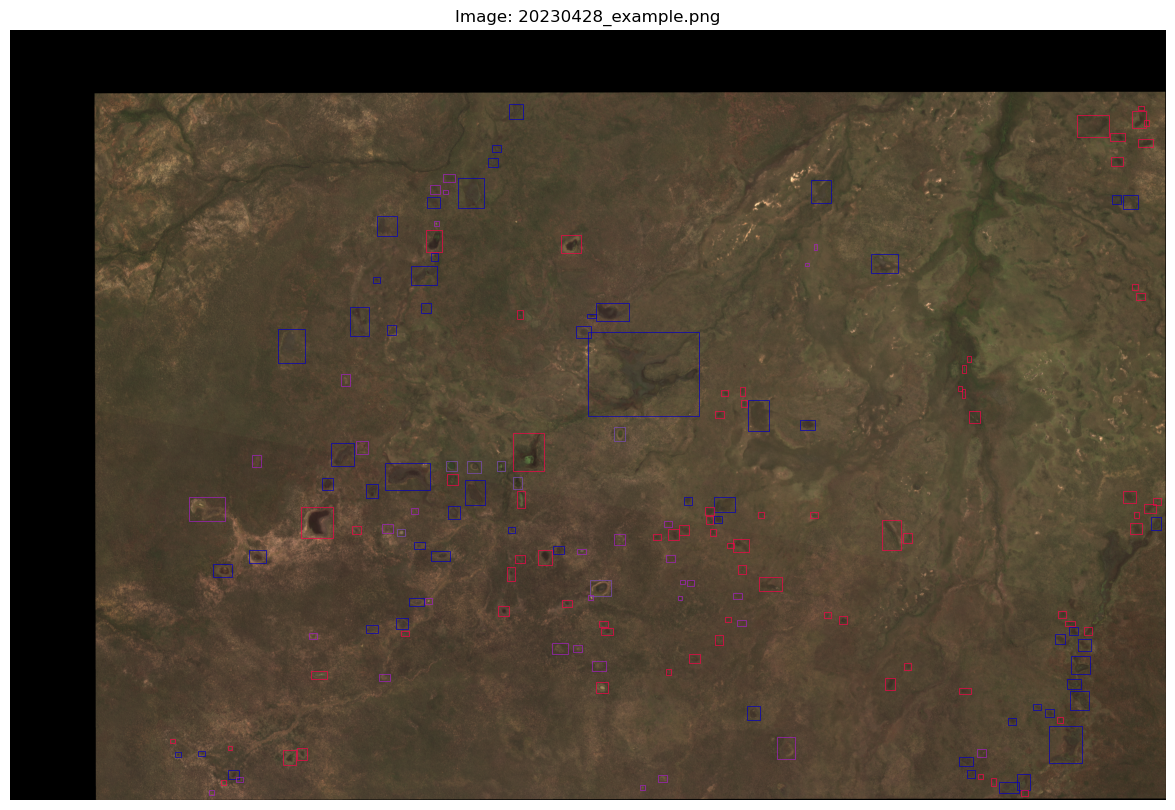

{'Dry_WH': (0.6330330804811461, 0.12746168285748138, 0.7421996200424823),
 'WH_wet': (0.9483396780730796, 0.01994384804549154, 0.2860761056204556),
 'WH_sink': (0.48343581601830676, 0.3035129164794228, 0.7101719845506764),
 'WH_swamp': (0.020700848244670556, 0.0004582288558682146, 0.7488610572215624)}

In [11]:
plot_labelme_bboxes(
    image_dir=r"C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\images\pngs", 
    label_dir=r"C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\images\Labels",
    output_dir=r"C:\Users\fossatia\Documents\Waterholes_project\counting_waterholes\results\Check_whole_image"
)